# SAD — Motor de Score de Atribuição de OS

Objetivo: demonstrar o funcionamento do motor de score — como cada componente
é calculado e como a sugestão de atribuição é gerada.

**Banco:** PostgreSQL — sad_logistica  
**Dados:** sintéticos, 90 dias de operação simulada  
**Motor:** score = tempo_base + custo_distancia + custo_congestao

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sqlalchemy import create_engine
from dotenv import load_dotenv
from pathlib import Path
from urllib.parse import quote_plus

sys.path.append(str(Path("..") / "src"))
from config import WAREHOUSE_LAYOUT

env_path = Path("..") / ".env"
load_dotenv(env_path)

db_password = quote_plus(os.getenv("DB_PASSWORD"))

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{db_password}@"
    f"{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

print("Conexão OK")

Conexão OK


In [2]:
df_operadores = pd.read_sql("""
    WITH ultima_os AS (
        SELECT DISTINCT ON (ex.operador_id)
            ex.operador_id,
            ex.os_id,
            ex.fim
        FROM execucoes ex
        WHERE ex.status = 'finalizada'
        ORDER BY ex.operador_id, ex.fim DESC
    )
    SELECT
        op.id,
        op.nome,
        MAX(ed.deposito_id) AS deposito_id,
        AVG(ed.rua)         AS rua_media,
        AVG(ed.predio)      AS predio_media,
        AVG(ed.nivel)       AS nivel_media,
        AVG(ed.apartamento) AS apto_media,
        u.fim               AS ultima_execucao
    FROM operadores op
    JOIN ultima_os u  ON u.operador_id = op.id
    JOIN os_itens oi  ON oi.os_id = u.os_id
    JOIN enderecos ed ON ed.id = oi.endereco_id
    WHERE op.ativo = TRUE
    GROUP BY op.id, op.nome, u.os_id, u.fim
""", engine)

print(f"Operadores com posição estimada: {len(df_operadores)}")
df_operadores.head(10)

Operadores com posição estimada: 50


,id,nome,deposito_id,rua_media,predio_media,nivel_media,apto_media,ultima_execucao
0,18,Maria Vitória Moreira,1,6.916667,3.166667,1.500000,2.666667,2026-03-30 09:30:52.559920
1,45,Alexia Leão,1,8.000000,2.000000,2.000000,4.000000,2026-03-12 17:47:26.559920
2,50,Antony Pacheco,2,3.500000,2.000000,2.500000,2.500000,2026-03-28 08:31:51.559920
3,11,Lorenzo Machado,1,5.200000,2.600000,1.400000,3.000000,2026-03-16 07:40:44.559920
4,9,Emanuella Macedo,1,3.600000,3.800000,1.400000,1.800000,2026-04-03 13:19:39.559920
5,2,Gabriel Gonçalves,1,2.000000,5.000000,1.000000,4.000000,2026-04-02 11:06:05.559920
6,17,Sabrina Cavalcanti,2,3.428571,2.285714,2.285714,2.571429,2026-03-20 10:19:13.559920
7,4,João Guilherme Rodrigues,2,5.500000,2.750000,2.250000,3.000000,2026-03-27 16:47:15.559920
8,7,Rafael Aragão,1,6.500000,3.500000,1.500000,2.000000,2026-04-02 07:59:46.559920
9,34,Luigi Ramos,1,3.000000,4.000000,1.666667,4.000000,2026-03-24 11:40:48.559920


## Posição Estimada dos Operadores

A posição de cada operador é estimada pelo **centroide da última OS executada** - 
média das coordenadas (rua, prédio, nível, apartamento) dos itens coletados.

Na ausência de rastreamento em tempo real (RFID, GPS indoor), essa é a melhor 
aproximação disponível com os dados registrados no sistema.

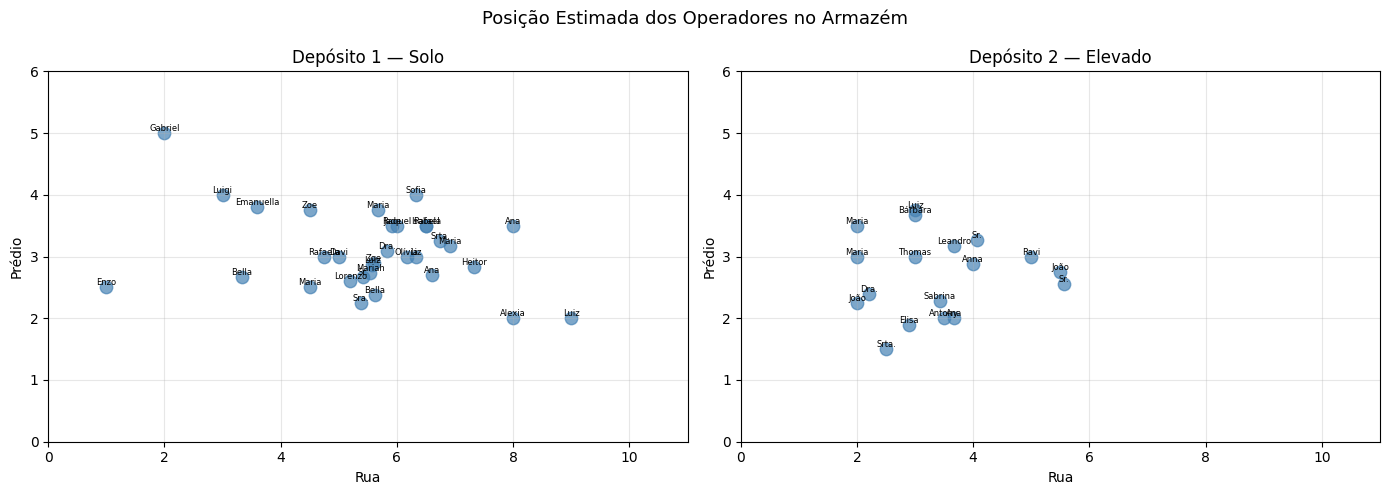

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dep_id, titulo in zip(
    axes,
    [1, 2],
    ["Depósito 1 — Solo", "Depósito 2 — Elevado"]
):
    dep = df_operadores[df_operadores["deposito_id"] == dep_id]
    ax.scatter(
        dep["rua_media"],
        dep["predio_media"],
        alpha=0.7,
        s=80,
        color="steelblue"
    )
    for _, row in dep.iterrows():
        ax.annotate(
            row["nome"].split()[0],
            (row["rua_media"], row["predio_media"]),
            fontsize=6,
            ha="center",
            va="bottom"
        )
    ax.set_title(titulo)
    ax.set_xlabel("Rua")
    ax.set_ylabel("Prédio")
    ax.set_xlim(0, 11)
    ax.set_ylim(0, 6)
    ax.grid(True, alpha=0.3)

plt.suptitle("Posição Estimada dos Operadores no Armazém", fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
df_os_pendentes = pd.read_sql("""
    SELECT
        o.id           AS os_id,
        o.tipo_codigo,
        ot.descricao   AS tipo_os,
        MAX(ed.deposito_id) AS deposito_id,
        AVG(ed.rua)         AS rua_media,
        AVG(ed.predio)      AS predio_media,
        COUNT(oi.id)        AS total_itens
    FROM os o
    JOIN os_tipos ot ON ot.codigo = o.tipo_codigo
    JOIN os_itens oi ON oi.os_id = o.id
    JOIN enderecos ed ON ed.id = oi.endereco_id
    WHERE o.status = 'pendente'
    GROUP BY o.id, o.tipo_codigo, ot.descricao
""", engine)

df_itens_pendentes = pd.read_sql("""
    SELECT
        o.id AS os_id,
        ed.deposito_id,
        ed.rua,
        ed.predio
    FROM os o
    JOIN os_itens oi ON oi.os_id = o.id
    JOIN enderecos ed ON ed.id = oi.endereco_id
    WHERE o.status = 'pendente'
""", engine)

print(f"OS pendentes: {len(df_os_pendentes)}")
df_os_pendentes

OS pendentes: 5


,os_id,tipo_codigo,tipo_os,deposito_id,rua_media,predio_media,total_itens
0,1,1,Separação Carrinho Fracionado,1,4.500000,3.250000,4
1,2,9,Separação Paletizado Caixa Fechada,1,5.363636,2.272727,11
2,3,9,Separação Paletizado Caixa Fechada,1,4.333333,2.333333,3
3,4,1,Separação Carrinho Fracionado,1,4.333333,3.333333,3
4,5,1,Separação Carrinho Fracionado,1,4.571429,2.428571,7


## OS Pendentes no Armazém

Cada OS pendente tem itens distribuídos em diferentes endereços.
O centroide representa a posição média dos itens — usado como referência
para estimar a distância do operador até a OS.

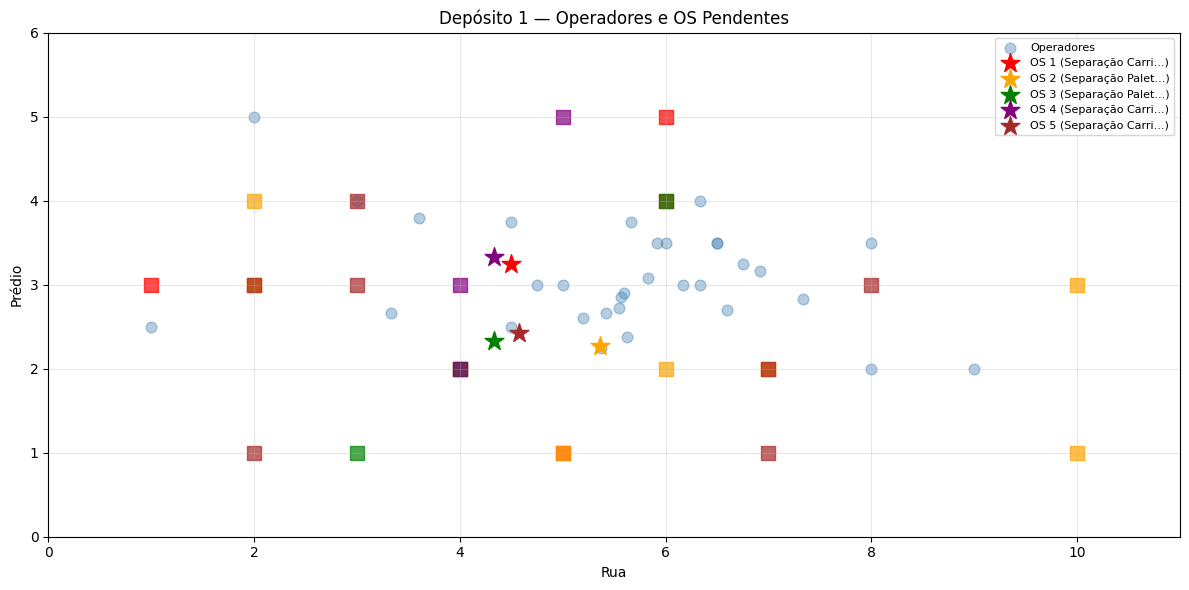

In [5]:
cores_os = ["red", "orange", "green", "purple", "brown"]

fig, ax = plt.subplots(figsize=(12, 6))

# Plota operadores do depósito 1
dep1 = df_operadores[df_operadores["deposito_id"] == 1]
ax.scatter(
    dep1["rua_media"], dep1["predio_media"],
    alpha=0.4, s=60, color="steelblue", label="Operadores"
)

# Plota cada OS pendente
for i, (_, os_row) in enumerate(df_os_pendentes[df_os_pendentes["deposito_id"] == 1].iterrows()):
    # Itens da OS
    itens = df_itens_pendentes[df_itens_pendentes["os_id"] == os_row["os_id"]]
    ax.scatter(
        itens["rua"], itens["predio"],
        s=100, color=cores_os[i], alpha=0.7, marker="s"
    )
    # Centroide
    ax.scatter(
        os_row["rua_media"], os_row["predio_media"],
        s=200, color=cores_os[i], marker="*",
        label=f"OS {os_row['os_id']} ({os_row['tipo_os'][:15]}...)"
    )

ax.set_title("Depósito 1 — Operadores e OS Pendentes")
ax.set_xlabel("Rua")
ax.set_ylabel("Prédio")
ax.set_xlim(0, 11)
ax.set_ylim(0, 6)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

## Interpretação do Gráfico

**Círculos azuis** - posição estimada de cada operador, baseada no centroide 
da última OS que executou.

**Quadrados coloridos** - endereços reais dos itens de cada OS pendente. 
Cada cor representa uma OS diferente. Os quadrados mostram onde o operador 
precisará ir fisicamente para coletar os itens.

**Estrelas coloridas** - centroide de cada OS (posição média de todos os seus itens).
Usada como referência visual, mas o motor de score calcula a distância 
item a item, não pelo centroide.

---

A sobreposição entre OS no gráfico é esperada nos dados sintéticos - em dados 
reais a distribuição refletiria o layout real do armazém e os padrões de 
separação da operação.

O motor identifica numericamente qual operador tem o menor custo estimado 
para executar cada OS, considerando posição, histórico e congestionamento.

In [6]:
# Demonstração do score para OS 1 e operador com menor score
from score import (
    buscar_operadores, buscar_baseline, buscar_os_pendentes,
    buscar_itens_os_pendentes, buscar_operadores_ativos,
    calcular_distancia_real, formatar_tempo
)

operadores        = buscar_operadores()
baseline          = buscar_baseline()
os_pendentes      = buscar_os_pendentes()
itens_pendentes   = buscar_itens_os_pendentes()
operadores_ativos = buscar_operadores_ativos()

# Pega a OS 1 e o operador sugerido (id 32)
os_demo      = os_pendentes[os_pendentes["os_id"] == 1].iloc[0]
itens_demo   = itens_pendentes[itens_pendentes["os_id"] == 1]
operador_demo = operadores[operadores["id"] == 32].iloc[0]

print("=== DEMONSTRAÇÃO DO SCORE ===\n")
print(f"Operador: {operador_demo['nome']}")
print(f"Posição estimada: Rua {operador_demo['rua_media']:.1f} | Prédio {operador_demo['predio_media']:.1f}")
print(f"\nOS: {int(os_demo['os_id'])} — {os_demo['tipo_os']}")
print(f"Total de itens: {len(itens_demo)}")
print(f"\nEndereços dos itens:")
print(itens_demo[["rua", "predio", "nivel", "apartamento"]].to_string(index=False))


=== SUGESTÕES DE ATRIBUIÇÃO ===

 operador_id         operador_nome  os_id                            tipo_os  tempo_base_seg tempo_base_formatado  custo_distancia  custo_congestao  score            alternativa
          32 Sra. Clarice Caldeira      1      Separação Carrinho Fracionado             550               9m 10s           210.21                0  761.1        Lorenzo Machado
          34           Luigi Ramos      2 Separação Paletizado Caixa Fechada            1135              18m 55s           529.43                0 1664.4          Raquel da Paz
          26         Raquel da Paz      3 Separação Paletizado Caixa Fechada            1471              24m 31s           173.99                0 1645.7 Ana Cecília Nascimento
          11       Lorenzo Machado      4      Separação Carrinho Fracionado             565               9m 25s           126.20                0  691.2        Rafaela Barbosa
          35       Rafaela Barbosa      5      Separação Carrinho Fracionado

In [7]:
# Calcula e decompõe o score item a item
CUSTO_APTO      = WAREHOUSE_LAYOUT["largura_apto_m"]     / WAREHOUSE_LAYOUT["velocidade_ms"]
CUSTO_PREDIO    = WAREHOUSE_LAYOUT["largura_predio_m"]   / WAREHOUSE_LAYOUT["velocidade_ms"]
CUSTO_CORREDOR  = WAREHOUSE_LAYOUT["largura_corredor_m"] / WAREHOUSE_LAYOUT["velocidade_ms"]
CUSTO_NIVEL     = WAREHOUSE_LAYOUT["custo_nivel_seg"]
PREDIOS_POR_RUA = WAREHOUSE_LAYOUT["predios_por_rua"]

rua_op         = round(operador_demo["rua_media"])
ruas_com_itens = set(itens_demo["rua"].unique())
ruas_com_itens_lista = sorted([int(r) for r in ruas_com_itens])
rua_min        = min(rua_op, int(itens_demo["rua"].min()))
rua_max        = max(rua_op, int(itens_demo["rua"].max()))

print(f"Posição do operador: Rua {rua_op}")
print(f"Ruas com itens: {ruas_com_itens_lista}")
print(f"Percurso: Rua {rua_min} → Rua {rua_max}\n")
print(f"{'Rua':<6} {'Tipo':<25} {'Custo (s)':<12}")
print("-" * 45)

custo_total = 0

for rua in range(rua_min, rua_max + 1):
    if rua == rua_op:
        itens_rua = itens_demo[itens_demo["rua"] == rua]
        for _, item in itens_rua.iterrows():
            c = (abs(operador_demo["predio_media"] - item["predio"]) * CUSTO_PREDIO +
                 abs(operador_demo["apto_media"]   - item["apartamento"]) * CUSTO_APTO +
                 abs(operador_demo["nivel_media"]  - item["nivel"]) * CUSTO_NIVEL)
            print(f"{rua:<6} {'item (rua do operador)':<25} {c:.2f}s")
            custo_total += c
        if len(itens_rua) > 0:
            c_saida = abs(PREDIOS_POR_RUA - itens_rua["predio"].max()) * CUSTO_PREDIO
            print(f"{rua:<6} {'saída da rua':<25} {c_saida:.2f}s")
            custo_total += c_saida

    elif rua in ruas_com_itens:
        print(f"{rua:<6} {'corredor (entrada)':<25} {CUSTO_CORREDOR:.2f}s")
        custo_total += CUSTO_CORREDOR
        itens_rua = itens_demo[itens_demo["rua"] == rua]
        for _, item in itens_rua.iterrows():
            c = (abs(1 - item["predio"]) * CUSTO_PREDIO +
                 abs(item["apartamento"]) * CUSTO_APTO +
                 abs(item["nivel"]) * CUSTO_NIVEL)
            print(f"{rua:<6} {'item':<25} {c:.2f}s")
            custo_total += c
        c_saida = abs(PREDIOS_POR_RUA - itens_rua["predio"].max()) * CUSTO_PREDIO
        print(f"{rua:<6} {'saída da rua':<25} {c_saida:.2f}s")
        custo_total += c_saida

    else:
        print(f"{rua:<6} {'corredor (sem itens)':<25} {CUSTO_CORREDOR:.2f}s")
        custo_total += CUSTO_CORREDOR

print("-" * 45)
print(f"{'TOTAL custo_distancia':<31} {custo_total:.2f}s")
print(f"\nValor no motor de score: 210.21s")

Posição do operador: Rua 5
Ruas com itens: [1, 5, 6]
Percurso: Rua 1 → Rua 6

Rua    Tipo                      Custo (s)   
---------------------------------------------
1      corredor (entrada)        1.92s
1      item                      64.25s
1      saída da rua              3.54s
2      corredor (sem itens)      1.92s
3      corredor (sem itens)      1.92s
4      corredor (sem itens)      1.92s
5      item (rua do operador)    21.58s
5      saída da rua              7.08s
6      corredor (entrada)        1.92s
6      item                      66.37s
6      item                      37.78s
6      saída da rua              0.00s
---------------------------------------------
TOTAL custo_distancia           210.21s

Valor no motor de score: 210.21s


## Resultado Final das Sugestões

O motor avalia todas as combinações operador + OS e retorna a atribuição 
de menor score para cada OS, garantindo que cada operador apareça no máximo uma vez.

In [8]:
from score import sugerir_atribuicoes, formatar_tempo

sugestoes = sugerir_atribuicoes()
sugestoes["tempo_base_formatado"] = sugestoes["tempo_base_seg"].apply(formatar_tempo)
sugestoes["custo_distancia_fmt"]  = sugestoes["custo_distancia"].apply(lambda x: f"{x:.1f}s")
sugestoes["score_fmt"]            = sugestoes["score"].apply(lambda x: formatar_tempo(int(x)))

sugestoes = sugestoes[[
    "os_id", "tipo_os", "operador_nome",
    "tempo_base_formatado", "custo_distancia_fmt",
    "score_fmt", "alternativa"
]]

sugestoes.columns = [
    "OS", "Tipo", "Operador Sugerido",
    "Tempo Base", "Custo Distância",
    "Score Total", "Alternativa"
]

sugestoes

,OS,Tipo,Operador Sugerido,Tempo Base,Custo Distância,Score Total,Alternativa
0,1,Separação Carrinho Fracionado,Sra. Clarice Caldeira,9m 10s,210.2s,12m 41s,Lorenzo Machado
1,2,Separação Paletizado Caixa Fechada,Luigi Ramos,18m 55s,529.4s,27m 44s,Raquel da Paz
2,3,Separação Paletizado Caixa Fechada,Raquel da Paz,24m 31s,174.0s,27m 25s,Ana Cecília Nascimento
3,4,Separação Carrinho Fracionado,Lorenzo Machado,9m 25s,126.2s,11m 31s,Rafaela Barbosa
4,5,Separação Carrinho Fracionado,Rafaela Barbosa,10m 44s,379.4s,17m 4s,Luiz Felipe Nogueira


## Conclusão

O motor de score v5 sugere atribuições baseadas em três fatores objetivos:

| Fator | O que mede |
|---|---|
| Tempo base | Velocidade histórica do operador naquele tipo de OS |
| Custo distância | Tempo estimado de deslocamento até os itens, rua a rua |
| Custo congestionamento | Tempo restante de operadores ativos na mesma zona |

**Exemplo de leitura da OS 1:**
- Operador sugerido: Sra. Clarice Caldeira
- Tempo base: 9m 10s (média histórica dela para Separação Carrinho)
- Custo distância: 210.2s (~3m 30s de deslocamento estimado)
- Score total: 12m 41s (atraso esperado se ela executar essa OS agora)
- Alternativa: Lorenzo Machado (segundo menor score)

O sistema não decide — ele informa. O gestor mantém o controle final.